In [10]:
from pathlib import Path
import backtest

EXPERIMENT    = "full_dataset_ic"       # matches results/final_<NAME>_reg.ubj
SECTORS       =  None #["financial_services"]        # None = all sectors
TOP_QUANTILE  = 0.2
BOT_QUANTILE  = 0                # 0 = long-only
REBALANCE     = "fixed"               # "fixed" | "staggered"
MIN_STOCKS    = 3
OUTPUT_DIR    = Path("backtest_results")

In [11]:
df = backtest.load_dataset(SECTORS)
START, END = backtest.infer_test_window(df)
print(f"Test window: {START}  →  {END}")

Dataset: 146,809 rows | 3,773 tickers
Test window: 2023-03-31  →  2026-03-15


Loaded  final_full_dataset_ic_reg.ubj  (100 feats | train IC=0.0837 ICIR=1.1339)
Dataset: 146,809 rows | 3,773 tickers

Backtest  2023Q1 → 2026Q1  (13 Qs)  mode=fixed  long=20%  short=0%



Quarters:   8%|▊         | 1/12 [00:01<00:12,  1.13s/it]

2023Q1 n=3032→607 long=+6.38%  comb=+6.38% SPY≈+8.68%  alpha=-2.30% IC(Batch)=+0.159


Quarters:  17%|█▋        | 2/12 [00:02<00:15,  1.53s/it]

2023Q2 n=3079→616 long=-3.29%  comb=-3.29% SPY≈-3.26%  alpha=-0.03% IC(Batch)=+0.144


...

Quarters:  92%|█████████▏| 11/12 [00:13<00:01,  1.07s/it]

Quarter: 2025Q3 is after 2025Q2, can't derive Batch IC because target is unavailable (requires one year of future data)
2025Q3 n=3530→706 long=-4.70%  comb=-4.70% SPY≈+2.67%  alpha=-7.37% IC(Batch)=+nan


Quarters: 100%|██████████| 12/12 [00:14<00:00,  1.20s/it]

Quarter: 2025Q4 is after 2025Q2, can't derive Batch IC because target is unavailable (requires one year of future data)
2025Q4 n=3510→702 long=-2.93%  comb=-2.93% SPY≈-4.37%  alpha=+1.44% IC(Batch)=+nan
Risk-free rates loaded: mean=1.113%/qtr  (4.45% annualised)

─── Backtest Summary ────────────────────────────────────────────────
  Mode                  : fixed
  Risk-free rate (avg)  : 4.60%/yr  (^IRX T-bill)
  Quarters with results : 12 / 13
  Mean Batch IC        : +0.0957  (std=0.0642)

  Long leg
    Mean qtrly return   : +6.58%
    Annualised Sharpe   : 1.116
    Win rate            : 58.3%
    Max drawdown        : -7.49%

  Combined L/S
    Mean qtrly return   : +6.58%
    Annualised Sharpe   : 1.116
    Total return        : +104.98%
    Max drawdown        : -7.49%

  SPY benchmark (per-position avg window)
    Mean qtrly return   : +4.42%
    Annualised Sharpe   : 1.124
    Total return        : +65.08%
    Max drawdown        : -4.37%

  Mean position-level alpha : +2.16%

Plot   → backtest_results/backtest_full_dataset_ic_fixed_plot.png


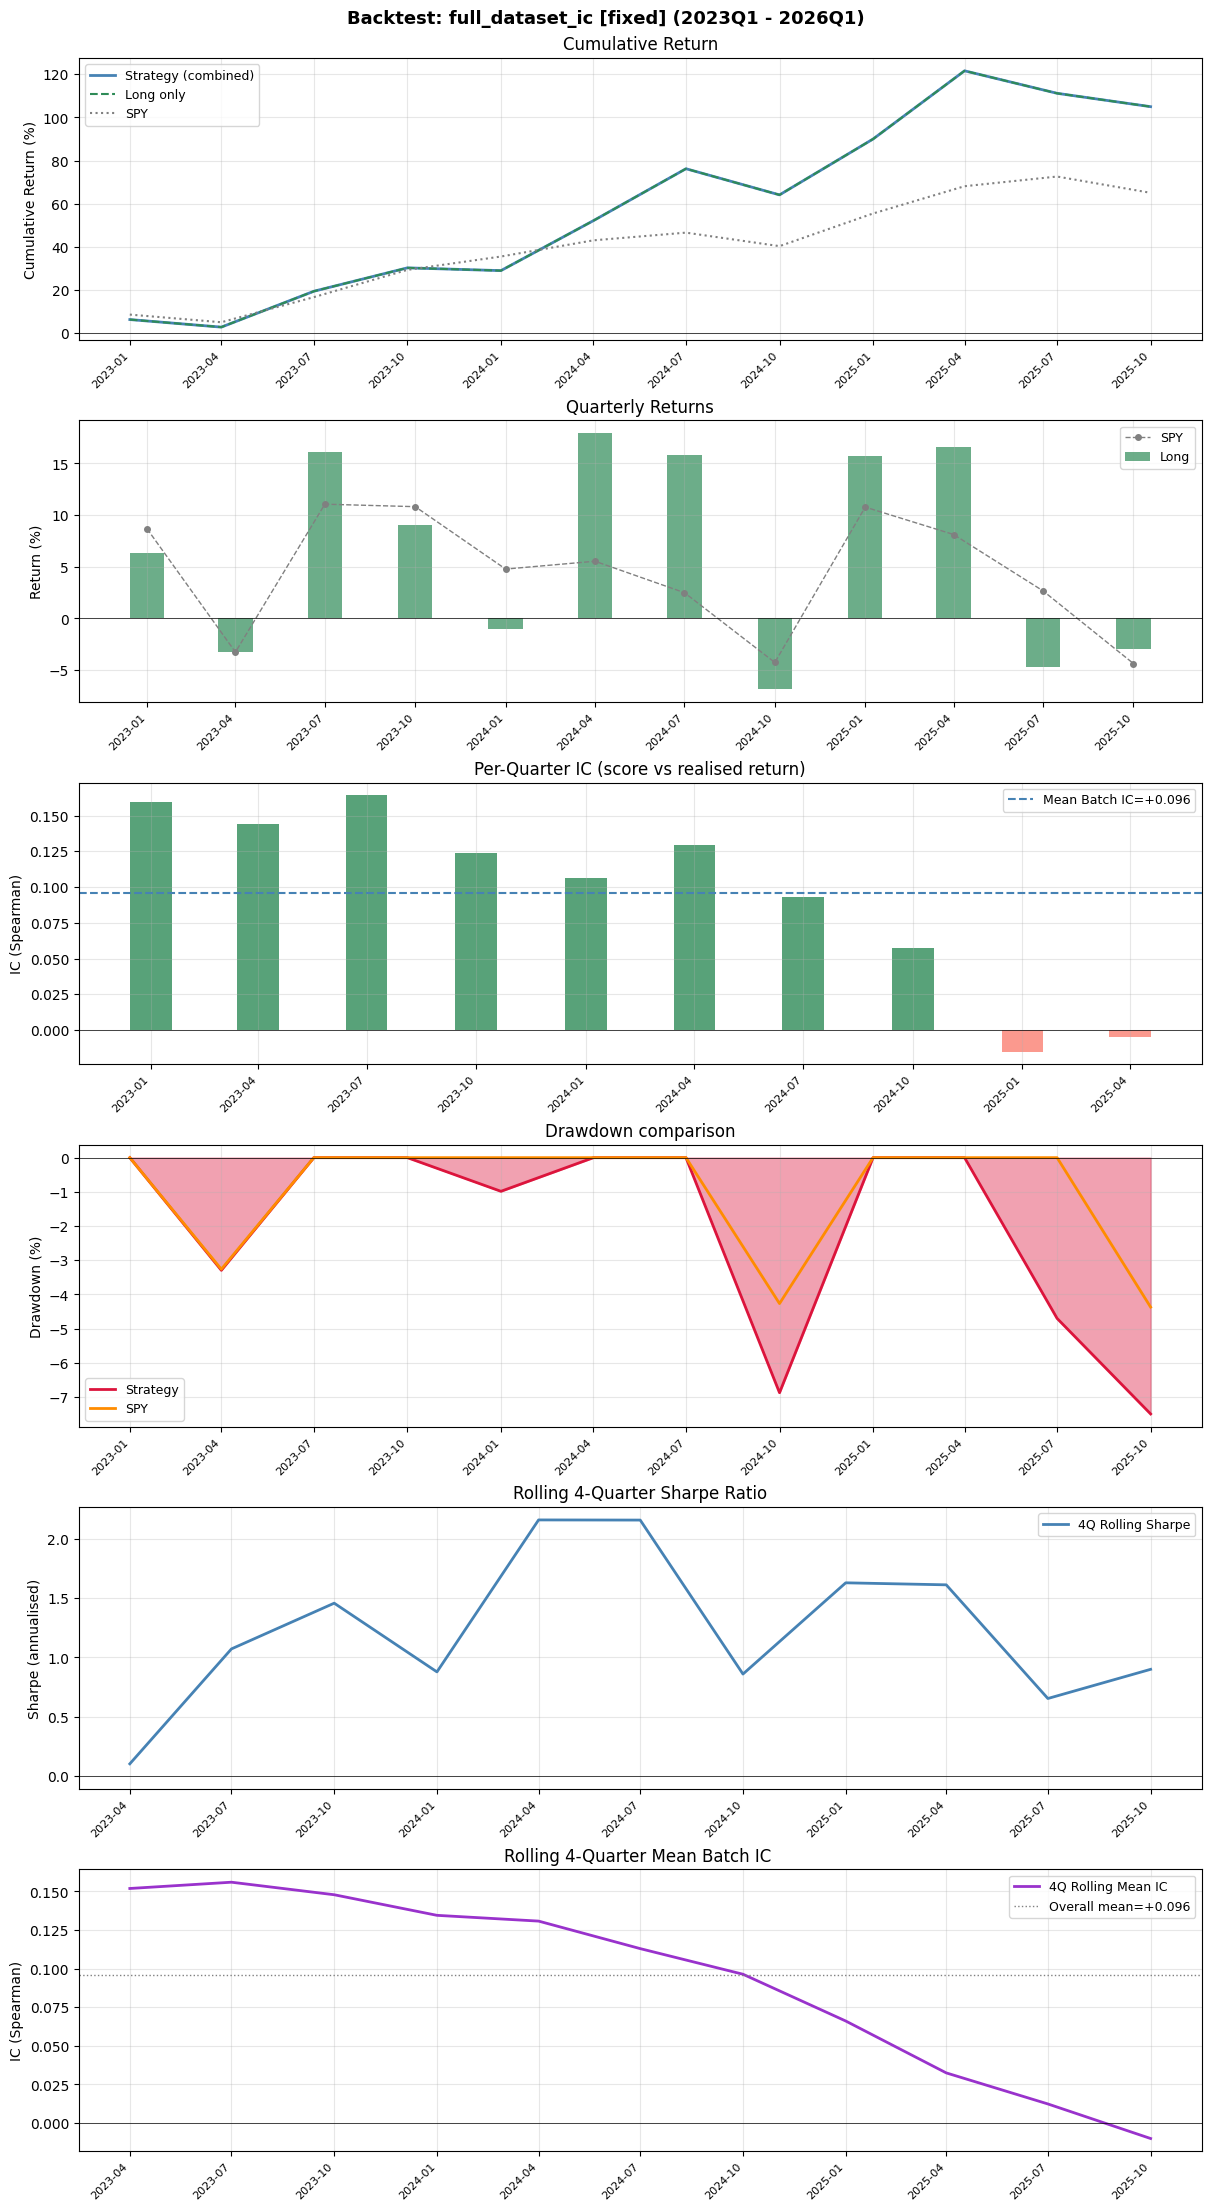

In [12]:
results = backtest.run_backtest(
    experiment_name = EXPERIMENT,
    sectors         = SECTORS,
    top_q           = TOP_QUANTILE,
    bot_q           = BOT_QUANTILE,
    start_date      = START,
    end_date        = END,
    rebalance_mode  = REBALANCE,
    # max_hold_days   = MAX_HOLD_DAYS,
    min_stocks      = MIN_STOCKS,
    output_dir      = OUTPUT_DIR,
)